# Phase 1, Step 4 — Look at the data

Steps 2 and 3 are done: you have a clean signal (`goes_xrs.parquet`) and clean
labels (`flares.parquet`), independently cross-checked.

Step 4 has no machine learning in it. The whole point is to **see** your data
before you build labels on top of it, because a labelling bug is far cheaper to
catch with your eyes now than with a confused model in three weeks.

**How to run cells:** click a cell, press `Shift + Enter`. Run them in order the
first time. After that you can re-run any single cell without redoing the ones
above it — that is the entire reason we moved off the script.

## 1. Setup

In [1]:
import sys
print(sys.executable)

d:\Projects (2)\solar-flare-nowcast\venv\Scripts\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# This notebook lives in notebooks/, so data/ is one level up.
# The fallback keeps it working if you ever run from the project root instead.
DATA = Path("../data") if Path("../data").exists() else Path("data")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

SOFT = "#c0392b"   # xrsb  - long channel  (1-8 A)
HARD = "#e67e22"   # xrsa  - short channel (0.5-4 A)

## 2. Load what you saved

No downloading here — this reads the Parquet files from disk, which is why
Step 4 starts instantly.

In [3]:
df = pd.read_parquet(DATA / "goes_xrs.parquet")
fl = pd.read_parquet(DATA / "flares.parquet")

# Parquet can round-trip these as strings; force real datetimes either way.
for c in ["event_starttime", "event_peaktime", "event_endtime"]:
    fl[c] = pd.to_datetime(fl[c])

print(f"Flux rows : {len(df):,}")
print(f"Flares    : {len(fl)}")
print(f"Range     : {df.index[0]}  ->  {df.index[-1]}")
print()
print(fl.head(3)[["event_starttime", "event_peaktime", "fl_goescls", "peak_flux"]])

Flux rows : 10,080
Flares    : 95
Range     : 2024-08-01 00:00:00  ->  2024-08-07 23:59:00

      event_starttime      event_peaktime fl_goescls  peak_flux
0 2024-08-01 00:01:00 2024-08-01 00:08:00       C9.3   0.000009
1 2024-08-01 00:28:00 2024-08-01 00:33:00       C8.3   0.000008
2 2024-08-01 00:50:00 2024-08-01 00:58:00       M1.2   0.000012


## 3. Why log scale is not optional

Your flux spans about two orders of magnitude in a quiet stretch and four during
a big flare. On a linear axis the largest event flattens everything else into a
line along the bottom.

Run this and compare the two panels. The **same data** is plotted twice.

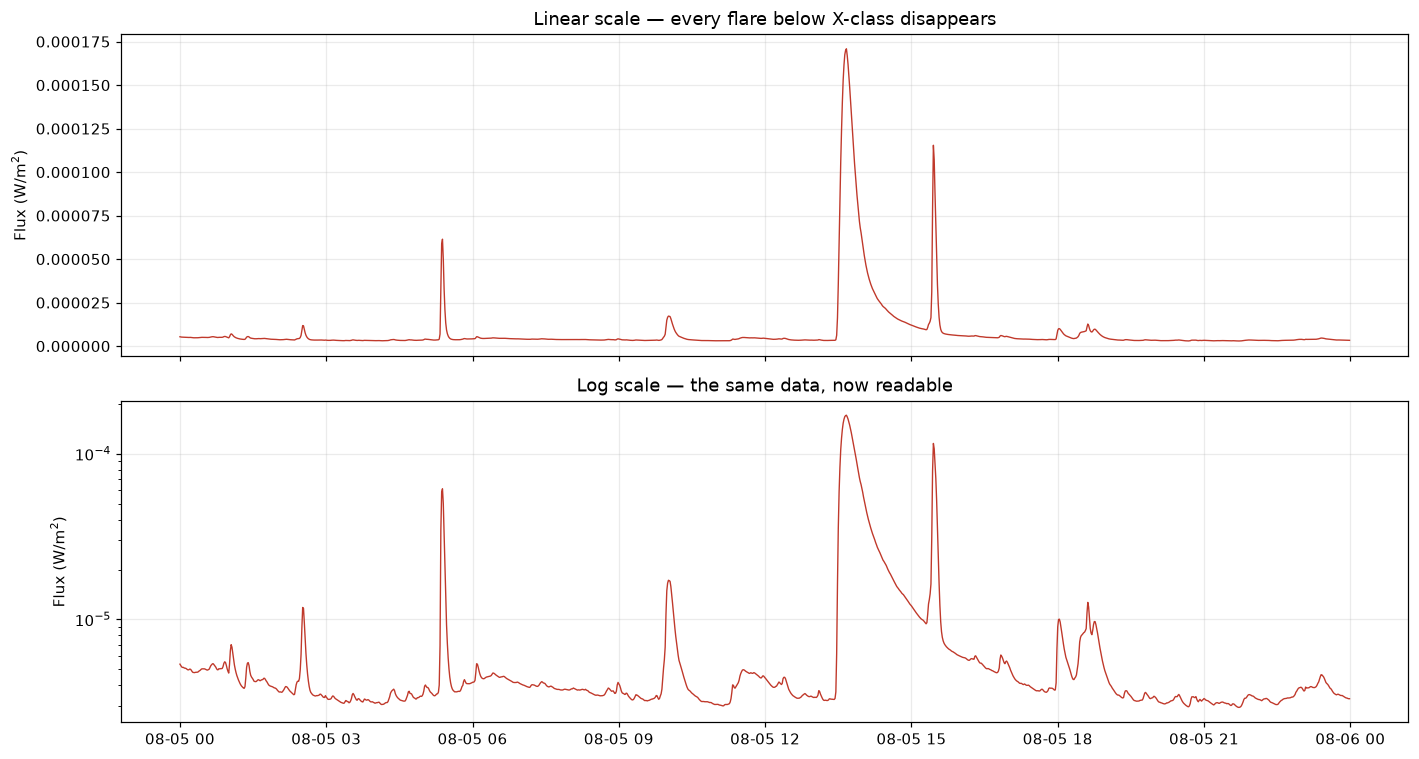

In [4]:
DAY = "2024-08-05"          # the day with both X-class flares
day = df.loc[DAY]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(day.index, day["xrsb"], lw=0.9, color=SOFT)
axes[0].set_title("Linear scale — every flare below X-class disappears")
axes[0].set_ylabel("Flux (W/m$^2$)")

axes[1].plot(day.index, day["xrsb"], lw=0.9, color=SOFT)
axes[1].set_yscale("log")
axes[1].set_title("Log scale — the same data, now readable")
axes[1].set_ylabel("Flux (W/m$^2$)")

plt.tight_layout()
plt.show()

**What you should see:** the top panel has one spike and a flat floor. The
bottom has structure everywhere — that flat floor was actually dozens of C and
M-class flares.

This is why every model input gets `log10` applied before it reaches a network.
A model reading linear flux would treat one X-class flare as more important than
every other event in the week combined.

## 4. Overlay the labels

Now the real check. Orange bands are flare start→end from the catalogue, dashed
lines mark the catalogued peak. **The bands must sit on top of the bumps.** If
they are offset, your labels and signal disagree and nothing built later will
work.

Flares on 2024-08-05: 9


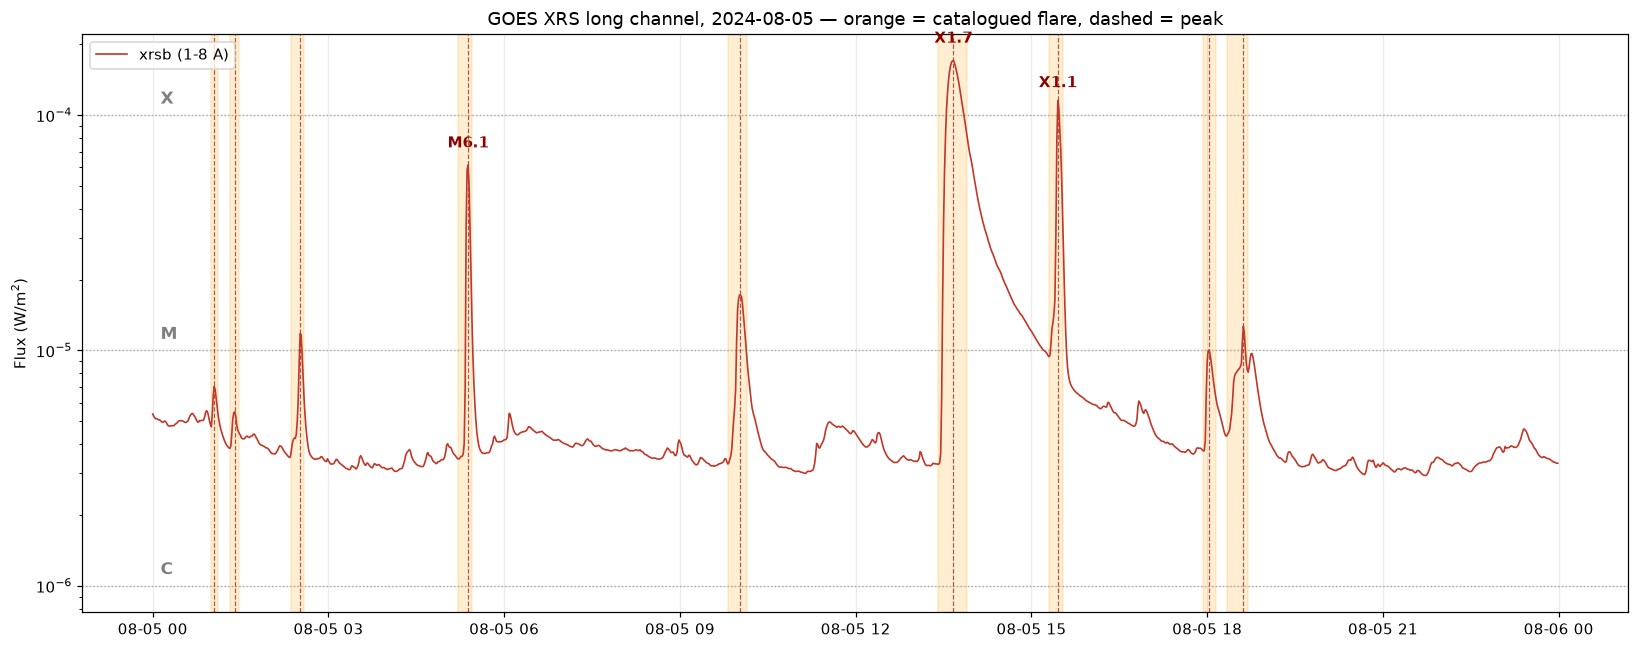

In [5]:
mask = (fl["event_starttime"] >= day.index[0]) & (fl["event_starttime"] <= day.index[-1])
day_flares = fl[mask]
print(f"Flares on {DAY}: {len(day_flares)}")

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(day.index, day["xrsb"], lw=1.1, color=SOFT, zorder=3, label="xrsb (1-8 A)")
ax.set_yscale("log")

# GOES class boundaries
for flux, letter in [(1e-6, "C"), (1e-5, "M"), (1e-4, "X")]:
    ax.axhline(flux, color="gray", ls=":", lw=0.9, alpha=0.7, zorder=1)
    ax.text(day.index[8], flux * 1.12, letter, color="gray",
            fontsize=11, weight="bold", zorder=4)

# catalogued flares
for _, f in day_flares.iterrows():
    ax.axvspan(f["event_starttime"], f["event_endtime"],
               color="orange", alpha=0.18, zorder=1)
    ax.axvline(f["event_peaktime"], color="darkred",
               ls="--", lw=0.8, alpha=0.65, zorder=2)

# label the big ones
for _, f in day_flares.iterrows():
    if f["peak_flux"] is not None and f["peak_flux"] >= 4e-5:
        ax.annotate(f["fl_goescls"],
                    xy=(f["event_peaktime"], f["peak_flux"]),
                    xytext=(0, 12), textcoords="offset points",
                    ha="center", fontsize=10, weight="bold", color="darkred")

ax.set_ylabel("Flux (W/m$^2$)")
ax.set_title(f"GOES XRS long channel, {DAY} — orange = catalogued flare, dashed = peak")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Check carefully:** does every orange band contain a rise? Does every dashed
line land on or near a local maximum? Are there obvious bumps with *no* band?

That last one matters most. Unlabelled bumps become false negatives your model
gets punished for finding — and they are usually real flares the catalogue chose
not to list, not model errors.

## 5. Zoom in on the X1.7

One flare, close up. This is the shape everything downstream has to recognise.

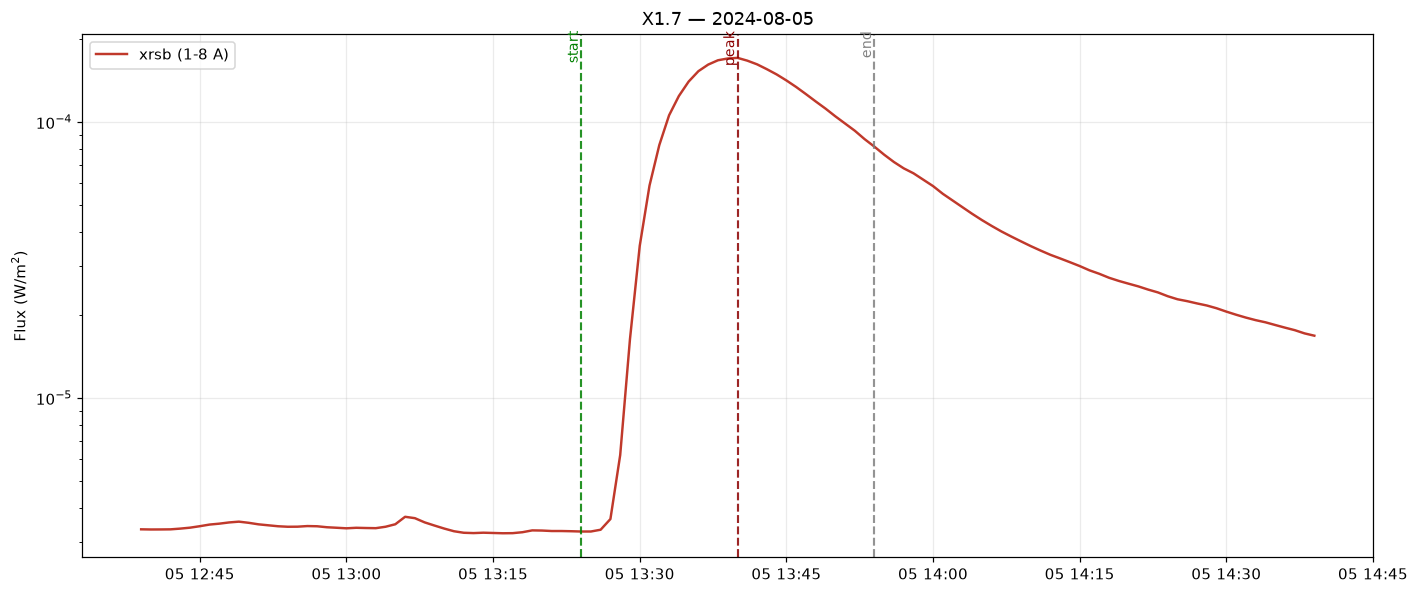

Rise  (start -> peak): 16 min   <-- your early-warning budget
Decay (peak -> end)  : 14 min


In [6]:
x17 = fl[fl["fl_goescls"] == "X1.7"].iloc[0]
pad = pd.Timedelta("45min")
w = df.loc[x17["event_starttime"] - pad : x17["event_endtime"] + pad]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(w.index, w["xrsb"], lw=1.6, color=SOFT, label="xrsb (1-8 A)")
ax.set_yscale("log")

for t, c, lab in [(x17["event_starttime"], "green", "start"),
                  (x17["event_peaktime"],  "darkred", "peak"),
                  (x17["event_endtime"],   "gray", "end")]:
    ax.axvline(t, color=c, ls="--", lw=1.4, alpha=0.85)
    ax.text(t, w["xrsb"].max() * 1.25, lab, rotation=90,
            color=c, fontsize=9, ha="right", va="top")

ax.set_ylabel("Flux (W/m$^2$)")
ax.set_title("X1.7 — 2024-08-05")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

rise = (x17["event_peaktime"] - x17["event_starttime"]).total_seconds() / 60
decay = (x17["event_endtime"] - x17["event_peaktime"]).total_seconds() / 60
print(f"Rise  (start -> peak): {rise:.0f} min   <-- your early-warning budget")
print(f"Decay (peak -> end)  : {decay:.0f} min")

**The number that defines your project:** that rise time is the entire window
in which an early warning is possible. Warn after the peak and you have built a
history logger, not a warning system.

Run the next cell to see the distribution across all 95 flares — the median is
the realistic target, not this one example.

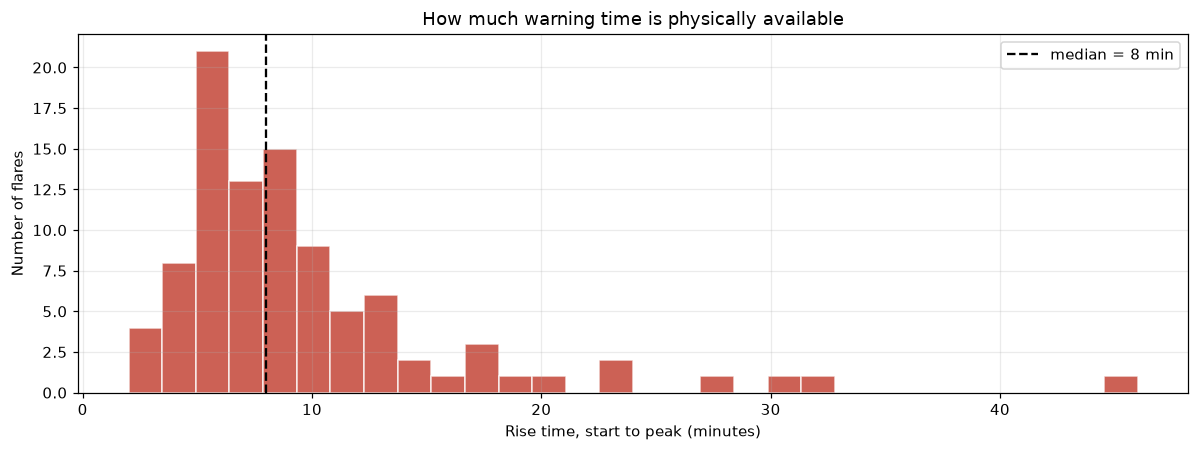

              count   50%  min   max
class_letter                        
C              43.0   7.0  2.0  30.0
M              50.0   9.0  3.0  46.0
X               2.0  12.5  9.0  16.0


In [7]:
fl["rise_min"] = (fl["event_peaktime"] - fl["event_starttime"]).dt.total_seconds() / 60

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.hist(fl["rise_min"], bins=30, color=SOFT, alpha=0.8, edgecolor="white")
ax.axvline(fl["rise_min"].median(), color="black", ls="--",
           label=f"median = {fl['rise_min'].median():.0f} min")
ax.set_xlabel("Rise time, start to peak (minutes)")
ax.set_ylabel("Number of flares")
ax.set_title("How much warning time is physically available")
ax.legend()
plt.tight_layout()
plt.show()

print(fl.groupby("class_letter")["rise_min"].describe()[["count", "50%", "min", "max"]])

## 6. The Neupert preview — and an honest caveat

Your project rests on the claim that hard X-rays behave like the *time derivative*
of soft X-rays, so the soft rise-rate forecasts the hard burst.

GOES gives a weak version of this test:

| Channel | Wavelength | Energy |
|---|---|---|
| `xrsb` | 1–8 Å | ~1.6–12 keV |
| `xrsa` | 0.5–4 Å | ~3–25 keV |

`xrsa` is harder than `xrsb`, so it should peak **earlier and sharper**. But it is
still mostly *thermal* emission — so expect a hint, not a clean result.

That gap is exactly your project's argument. HEL1OS covers **8–150 keV**: six
times higher in energy than GOES can reach, into the genuinely non-thermal range
where accelerated electrons live. This cell shows you what GOES can't do.

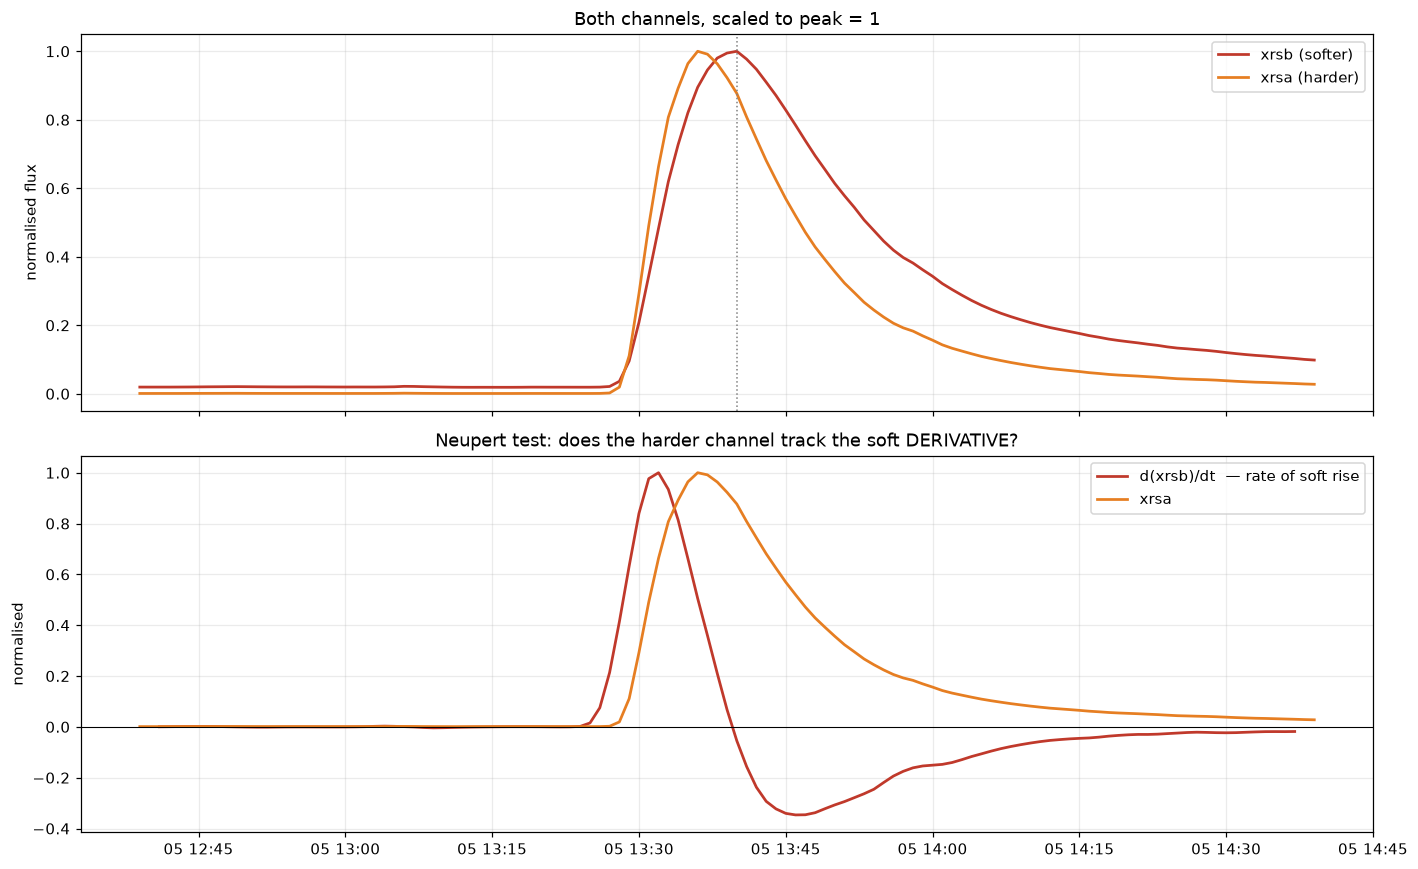

xrsb peaks at        : 2024-08-05 13:40:00
xrsa peaks at        : 2024-08-05 13:36:00
d(xrsb)/dt peaks at  : 2024-08-05 13:32:00

xrsa leads xrsb by 4 minutes


In [8]:
b = w["xrsb"].interpolate()      # interpolation here is for plotting only
a = w["xrsa"].interpolate()      # proper gap handling is Step 5

db = np.gradient(b.values)
db_s = pd.Series(db, index=b.index).rolling(5, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(b.index, b / b.max(), lw=1.8, color=SOFT, label="xrsb (softer)")
axes[0].plot(a.index, a / a.max(), lw=1.8, color=HARD, label="xrsa (harder)")
axes[0].axvline(x17["event_peaktime"], color="gray", ls=":", lw=1)
axes[0].set_ylabel("normalised flux")
axes[0].set_title("Both channels, scaled to peak = 1")
axes[0].legend()

axes[1].plot(db_s.index, db_s / db_s.max(), lw=1.8, color=SOFT,
             label="d(xrsb)/dt  — rate of soft rise")
axes[1].plot(a.index, a / a.max(), lw=1.8, color=HARD, label="xrsa")
axes[1].axhline(0, color="black", lw=0.7)
axes[1].set_ylabel("normalised")
axes[1].set_title("Neupert test: does the harder channel track the soft DERIVATIVE?")
axes[1].legend()

plt.tight_layout()
plt.show()

print("xrsb peaks at        :", b.idxmax())
print("xrsa peaks at        :", a.idxmax())
print("d(xrsb)/dt peaks at  :", db_s.idxmax())
print()
lead = (b.idxmax() - a.idxmax()).total_seconds() / 60
print(f"xrsa leads xrsb by {lead:.0f} minutes")

**Read the bottom panel carefully.** If the orange `xrsa` curve rises and falls
roughly in step with the soft derivative, you are seeing a partial Neupert effect
in data you downloaded yourself.

Report the three peak times back — they tell us whether GOES alone gives you any
usable lead, which determines how much of your early-warning claim rests on
HEL1OS rather than on the baseline.

## 7. Before moving on

Step 4 is done when you can answer these:

1. Do the orange bands line up with the rises?
2. Are there unlabelled bumps, and roughly how many?
3. What is the **median rise time** across all 95 flares?
4. Does `xrsa` peak before `xrsb`, and by how long?

Answers 3 and 4 set the target for the whole project. Step 5 is cleaning —
resampling, log-transforming, and dealing with those 21 missing values and the
quality flags.